In [46]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o dataset de breast-cancer-dataset.csv
df = pd.read_csv('datasets/breast-cancer-dataset.csv')

In [47]:
# Mostra as primeiras 5 linhas e informações gerais
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [48]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Observações importantes sobre o conjuntos de dados:

Total de colunas: 33 colunas

Informações dos atributos:

Número de identificação (ID)
Diagnóstico (M = maligno, B = benigno)

Dez características de valor real são calculadas para cada núcleo celular:

a - raio (média das distâncias do centro até os pontos do perímetro)

b - textura (desvio padrão dos valores em escala de cinza)

c - perímetro

d - área

e - suavidade (variação local dos comprimentos do raio)

f - compacidade (perímetro² / área − 1,0)

g - concavidade (gravidade das porções côncavas do contorno)

h - pontos côncavos (número de porções côncavas do contorno)

i - simetria

j - dimensão fractal (“aproximação da linha costeira” − 1)


A média, o erro padrão e o “pior” ou maior valor (média dos três maiores valores) dessas características foram calculados para cada imagem, resultando em 30 características. Por exemplo, o campo 3 corresponde ao Raio Médio, o campo 13 ao Erro Padrão do Raio, e o campo 23 ao Pior Raio.

Todos os valores das características foram recodificados com quatro algarismos significativos.
Valores de atributos ausentes: nenhum.
Distribuição das classes: 357 benignos, 212 malignos.


In [49]:
# Varrendo todas as colunas 
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")
    
# Verifica se a última coluna está vazia
last_col = df.columns[-1]
print(f"\nÚltima coluna: '{last_col}'")
print(f"Valores não-nulos: {df[last_col].notna().sum()} de {len(df)}")
print(f"Valores únicos: {df[last_col].nunique()}")


 1. id
 2. diagnosis
 3. radius_mean
 4. texture_mean
 5. perimeter_mean
 6. area_mean
 7. smoothness_mean
 8. compactness_mean
 9. concavity_mean
10. concave points_mean
11. symmetry_mean
12. fractal_dimension_mean
13. radius_se
14. texture_se
15. perimeter_se
16. area_se
17. smoothness_se
18. compactness_se
19. concavity_se
20. concave points_se
21. symmetry_se
22. fractal_dimension_se
23. radius_worst
24. texture_worst
25. perimeter_worst
26. area_worst
27. smoothness_worst
28. compactness_worst
29. concavity_worst
30. concave points_worst
31. symmetry_worst
32. fractal_dimension_worst
33. Unnamed: 32

Última coluna: 'Unnamed: 32'
Valores não-nulos: 0 de 569
Valores únicos: 0


Existe uma coluna vazia e vamos removê-la, assim como a coluna `id` que é apenas um identificador e não tem valor preditivo.


In [50]:
# Verifica valores ausentes em todas as colunas
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# Mostra apenas colunas com valores ausentes
missing_data = pd.DataFrame({
    'Coluna': missing_values.index,
    'Valores Ausentes': missing_values.values,
    'Percentual (%)': missing_percent.values
})
missing_data = missing_data[missing_data['Valores Ausentes'] > 0].sort_values('Valores Ausentes', ascending=False)

if len(missing_data) > 0:
    print("\n Colunas com valores ausentes:")
    print(missing_data.to_string(index=False))
else:
    print("\n Nenhum valor ausente encontrado!")

# Verifica colunas com muitos valores ausentes ou vazias
for col in df.columns:
    null_count = df[col].isnull().sum()
    if null_count > 0 or df[col].nunique() == 0:
        print(f"\n{col}': {null_count} valores ausentes, {df[col].nunique()} valores únicos")



 Colunas com valores ausentes:
     Coluna  Valores Ausentes  Percentual (%)
Unnamed: 32               569           100.0

Unnamed: 32': 569 valores ausentes, 0 valores únicos


In [51]:
# Remover coluna 'id' e coluna vazia
empty_cols = [col for col in df.columns if df[col].isnull().all()]

if 'id' in df.columns:
    df = df.drop(columns=['id'])

for col in empty_cols:
    df = df.drop(columns=[col])

A variável target será a coluna `diagnosis`, que classifica o tumor como:
- **B** = Benigno (não canceroso)
- **M** = Maligno (canceroso)


Verificaremos se as classes estão balanceadas. 

In [52]:
# Contagem de cada classe
target_counts = df['diagnosis'].value_counts()
target_percent = df['diagnosis'].value_counts(normalize=True) * 100

for classe in target_counts.index:
    count = target_counts[classe]
    percent = target_percent[classe]
    label = "B" if classe == 'B' else "M"
    print(f"{label}: {count:3d} casos ({percent:5.2f}%)")

print(f"\nTotal: {len(df)} casos")

# Balanceamento
ratio = min(target_counts) / max(target_counts)
print(f"\nRazão de balanceamento: {ratio:.2f}")

B: 357 casos (62.74%)
M: 212 casos (37.26%)

Total: 569 casos

Razão de balanceamento: 0.59


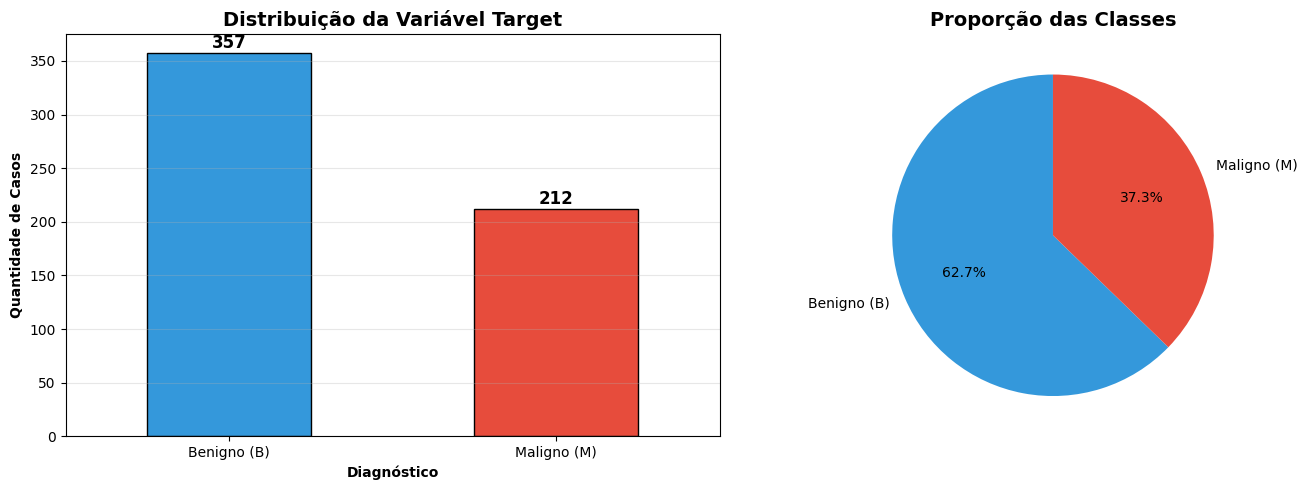

In [53]:
# Visualização da distribuição da variável target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
target_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribuição da Variável Target', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Diagnóstico', fontweight='bold')
axes[0].set_ylabel('Quantidade de Casos', fontweight='bold')
axes[0].set_xticklabels(['Benigno (B)', 'Maligno (M)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=12)

# Gráfico de pizza
colors = ['#3498db', '#e74c3c']
labels = ['Benigno (B)', 'Maligno (M)']
target_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors, 
                   startangle=90, labels=labels)
axes[1].set_title('Proporção das Classes', fontweight='bold', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


Vamos verificar as estatísticas descritivas:
- **Média**: valor central
- **Desvio padrão**: variabilidade dos dados
- **Valores mínimo e máximo**: faixa de valores
- **Quartis (25%, 50%, 75%)**: distribuição dos dados

In [54]:
# Separar apenas colunas numéricas (excluindo diagnosis)
numeric_cols = df.select_dtypes(include=[np.number]).columns
stats = df[numeric_cols].describe()

# Mostrar as estatísticas
stats


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


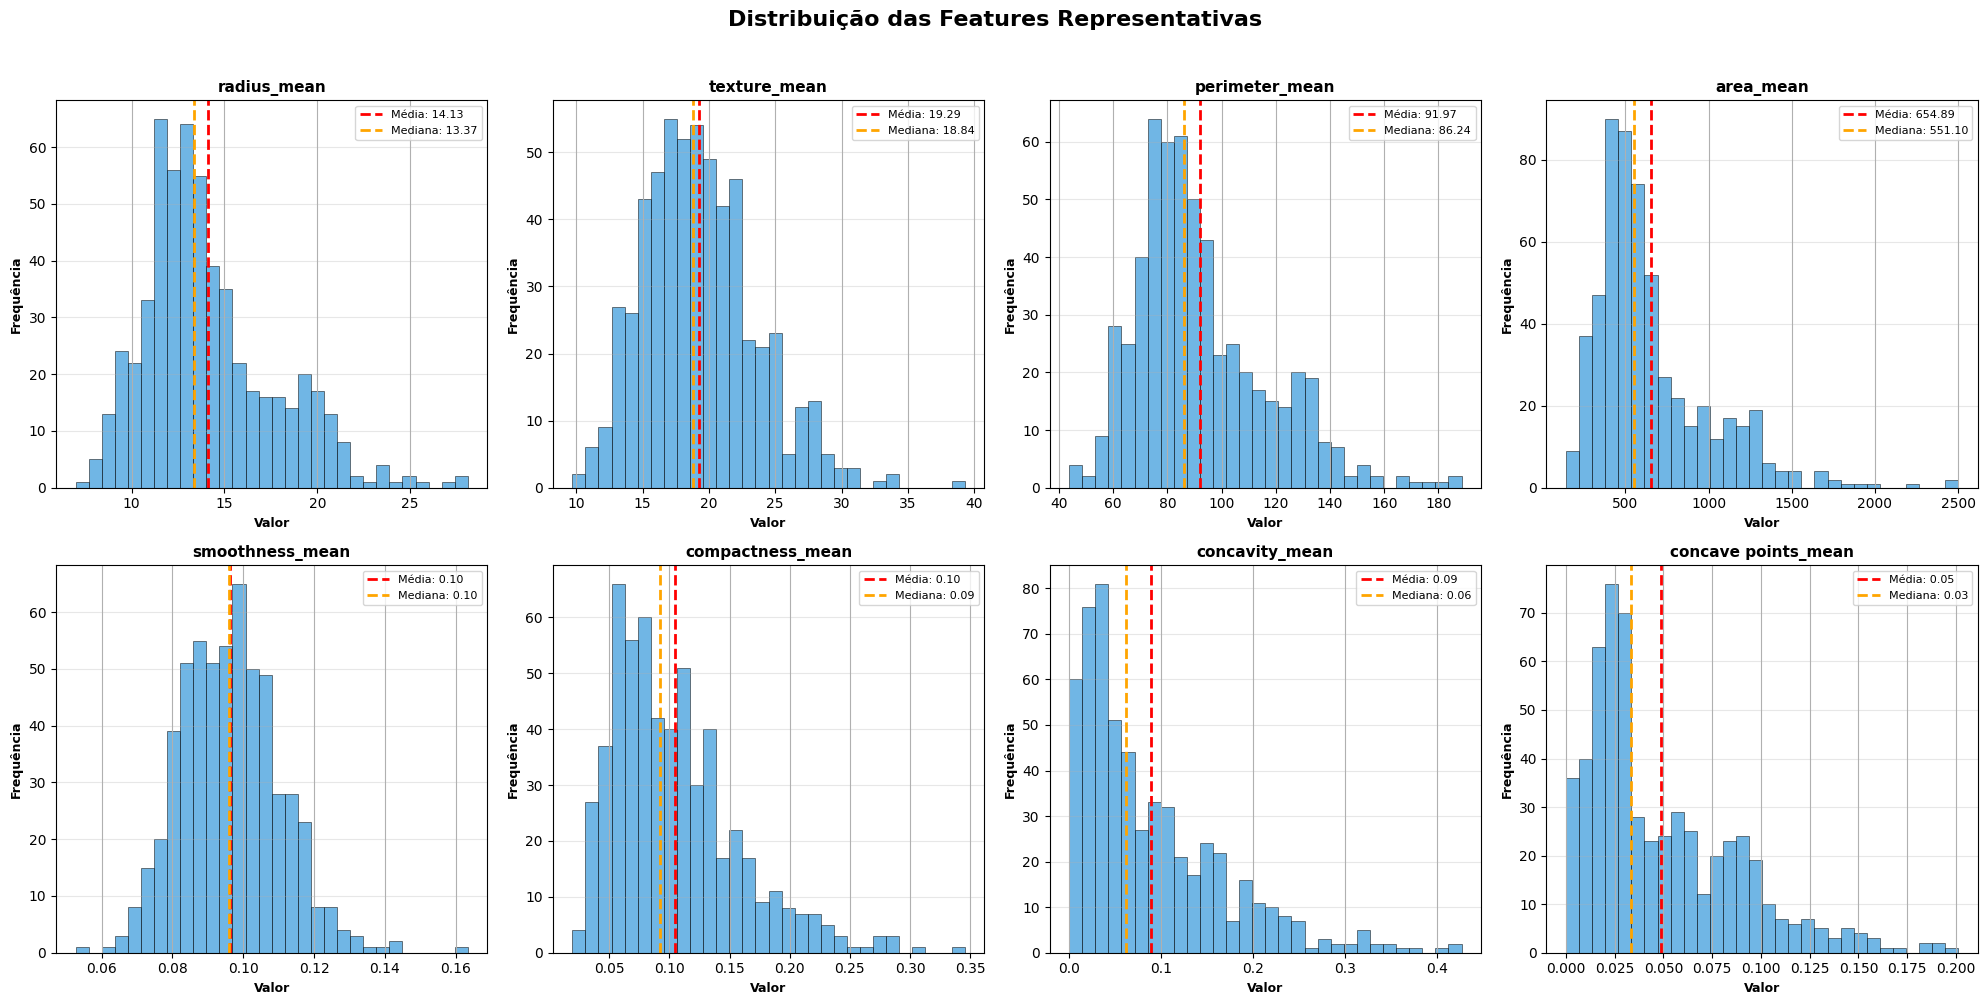

In [55]:
# Visualização da distribuição média dos dados
features_dist = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 
                 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean']

# Criar histogramas para visualizar a distribuição
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Distribuição das Features Representativas', fontweight='bold', fontsize=16, y=1.0)

axes = axes.flatten()

#histograma geral
for idx, feature in enumerate(features_dist):
    df[feature].hist(ax=axes[idx], bins=30, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[idx].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {df[feature].mean():.2f}')
    axes[idx].axvline(df[feature].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df[feature].median():.2f}')
    axes[idx].set_title(f'{feature}', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Valor', fontweight='bold', fontsize=9)
    axes[idx].set_ylabel('Frequência', fontweight='bold', fontsize=9)
    axes[idx].legend(fontsize=8, loc='upper right')
    axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


A correlação mede a relação linear entre duas variáveis. Algumas observaçÕes sobre a correlação:
- Features muito correlacionadas podem ser redundantes
- Correlação alta com a variável target indica features importantes
- Multicolinearidade (correlação alta entre features) pode afetar alguns modelos
- Quanto maior a correlação, mais importante a feature para prever o diagnóstico


In [56]:
# Primeiro, vamos codificar a variável target (B=0, M=1) para incluir na correlação
df_corr = df.copy()
df_corr['diagnosis_encoded'] = df_corr['diagnosis'].map({'B': 0, 'M': 1})

# Calcula a correlação com a variável target
correlation_with_target = df_corr[numeric_cols].corrwith(df_corr['diagnosis_encoded']).abs().sort_values(ascending=False)

# Exibir as 10 features mais correlacionadas
for i, (feature, corr) in enumerate(correlation_with_target.head(10).items(), 1):
    print(f"{i:2d}. {feature:30s}: {corr:.4f}")


 1. concave points_worst          : 0.7936
 2. perimeter_worst               : 0.7829
 3. concave points_mean           : 0.7766
 4. radius_worst                  : 0.7765
 5. perimeter_mean                : 0.7426
 6. area_worst                    : 0.7338
 7. radius_mean                   : 0.7300
 8. area_mean                     : 0.7090
 9. concavity_mean                : 0.6964
10. concavity_worst               : 0.6596


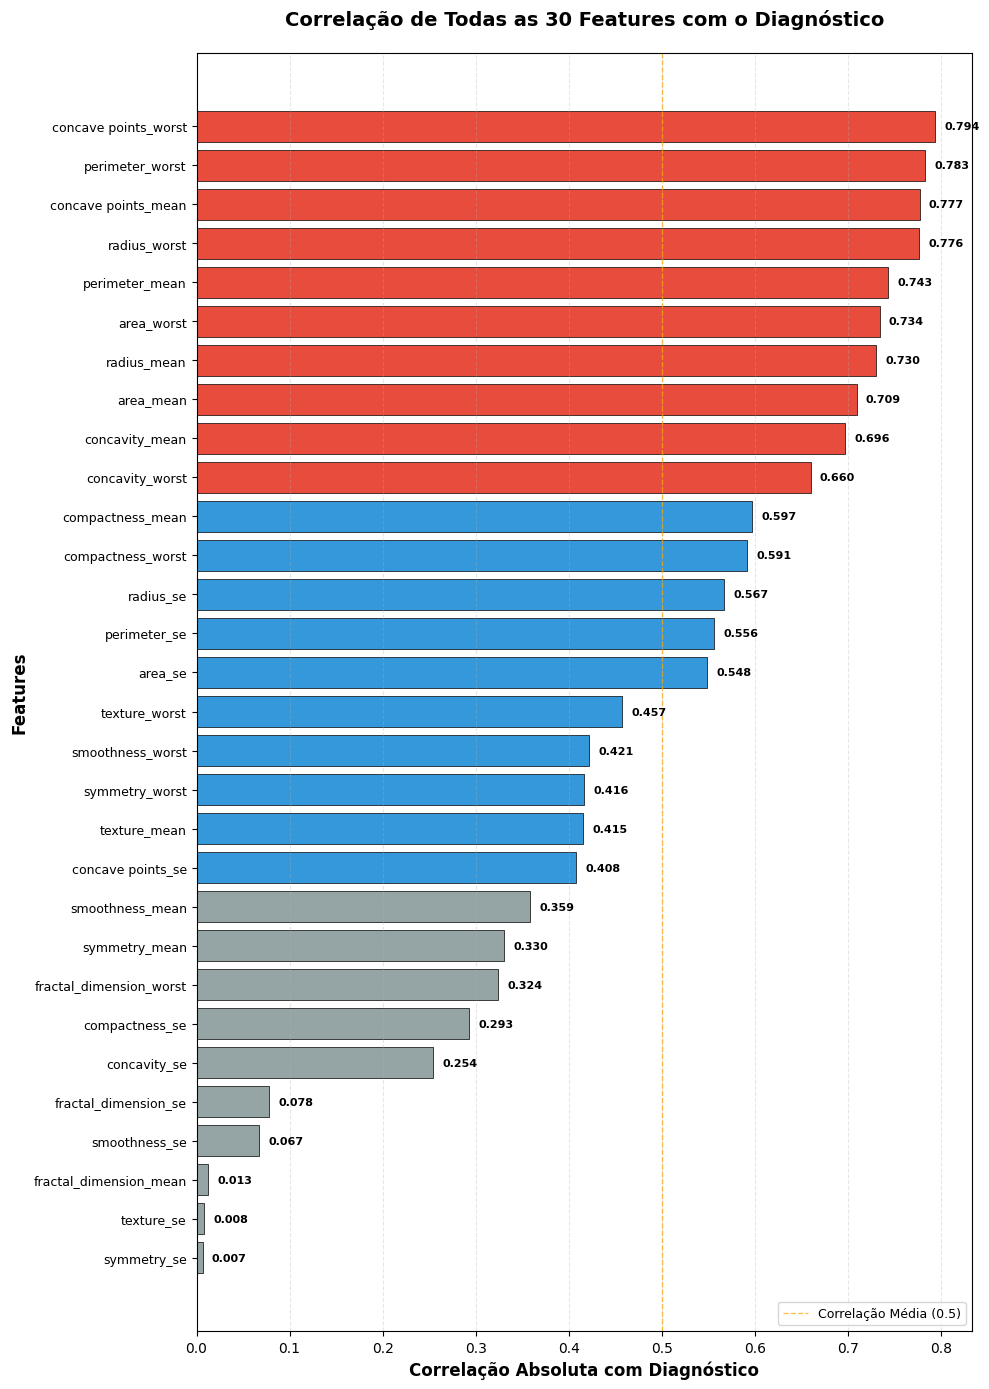

In [57]:
# Gráfico de barras de correlação de todas as 30 features com o target
# Ordenando todas as correlações (absolutas) por valor
correlation_all = df_corr[numeric_cols].corrwith(df_corr['diagnosis_encoded']).abs().sort_values(ascending=True)

# Criar gráfico de barras horizontal
plt.figure(figsize=(10, 14))
colors = ['#e74c3c' if corr > 0.6 else '#3498db' if corr > 0.4 else '#95a5a6' for corr in correlation_all.values]
bars = plt.barh(range(len(correlation_all)), correlation_all.values, color=colors, edgecolor='black', linewidth=0.5)

plt.yticks(range(len(correlation_all)), correlation_all.index, fontsize=9)
plt.xlabel('Correlação Absoluta com Diagnóstico', fontweight='bold', fontsize=12)
plt.ylabel('Features', fontweight='bold', fontsize=12)
plt.title('Correlação de Todas as 30 Features com o Diagnóstico', fontweight='bold', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Adicionar valores nas barras
for i, (idx, corr) in enumerate(correlation_all.items()):
    plt.text(corr + 0.01, i, f'{corr:.3f}', va='center', fontsize=8, fontweight='bold')

# Adicionar linha vertical de referência
plt.axvline(x=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Correlação Média (0.5)')
plt.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


A interpretação da matriz de correlação:

- Valores próximos de +1: correlação positiva forte (quando uma aumenta, a outra aumenta)
- Valores próximos de -1: correlação negativa forte (quando uma aumenta, a outra diminui)
- Valores próximos de 0: pouca ou nenhuma correlação

O heatmap de correlação identifica padrões de relacionamento entre variáveis 
- Detecta multicolinearidade, evidenciando variáveis altamente correlacionadas (próximas de +1 ou −1) 
- Auxilia diretamente na seleção de features ao destacar quais atributos possuem maior correlação com o target e quais apresentam correlação forte entre si
- Contribui para a otimização dos modelos ao apoiar a redução de dimensionalidade, minimizar riscos de overfitting e melhorar a performance geral dos algoritmos de classificação.

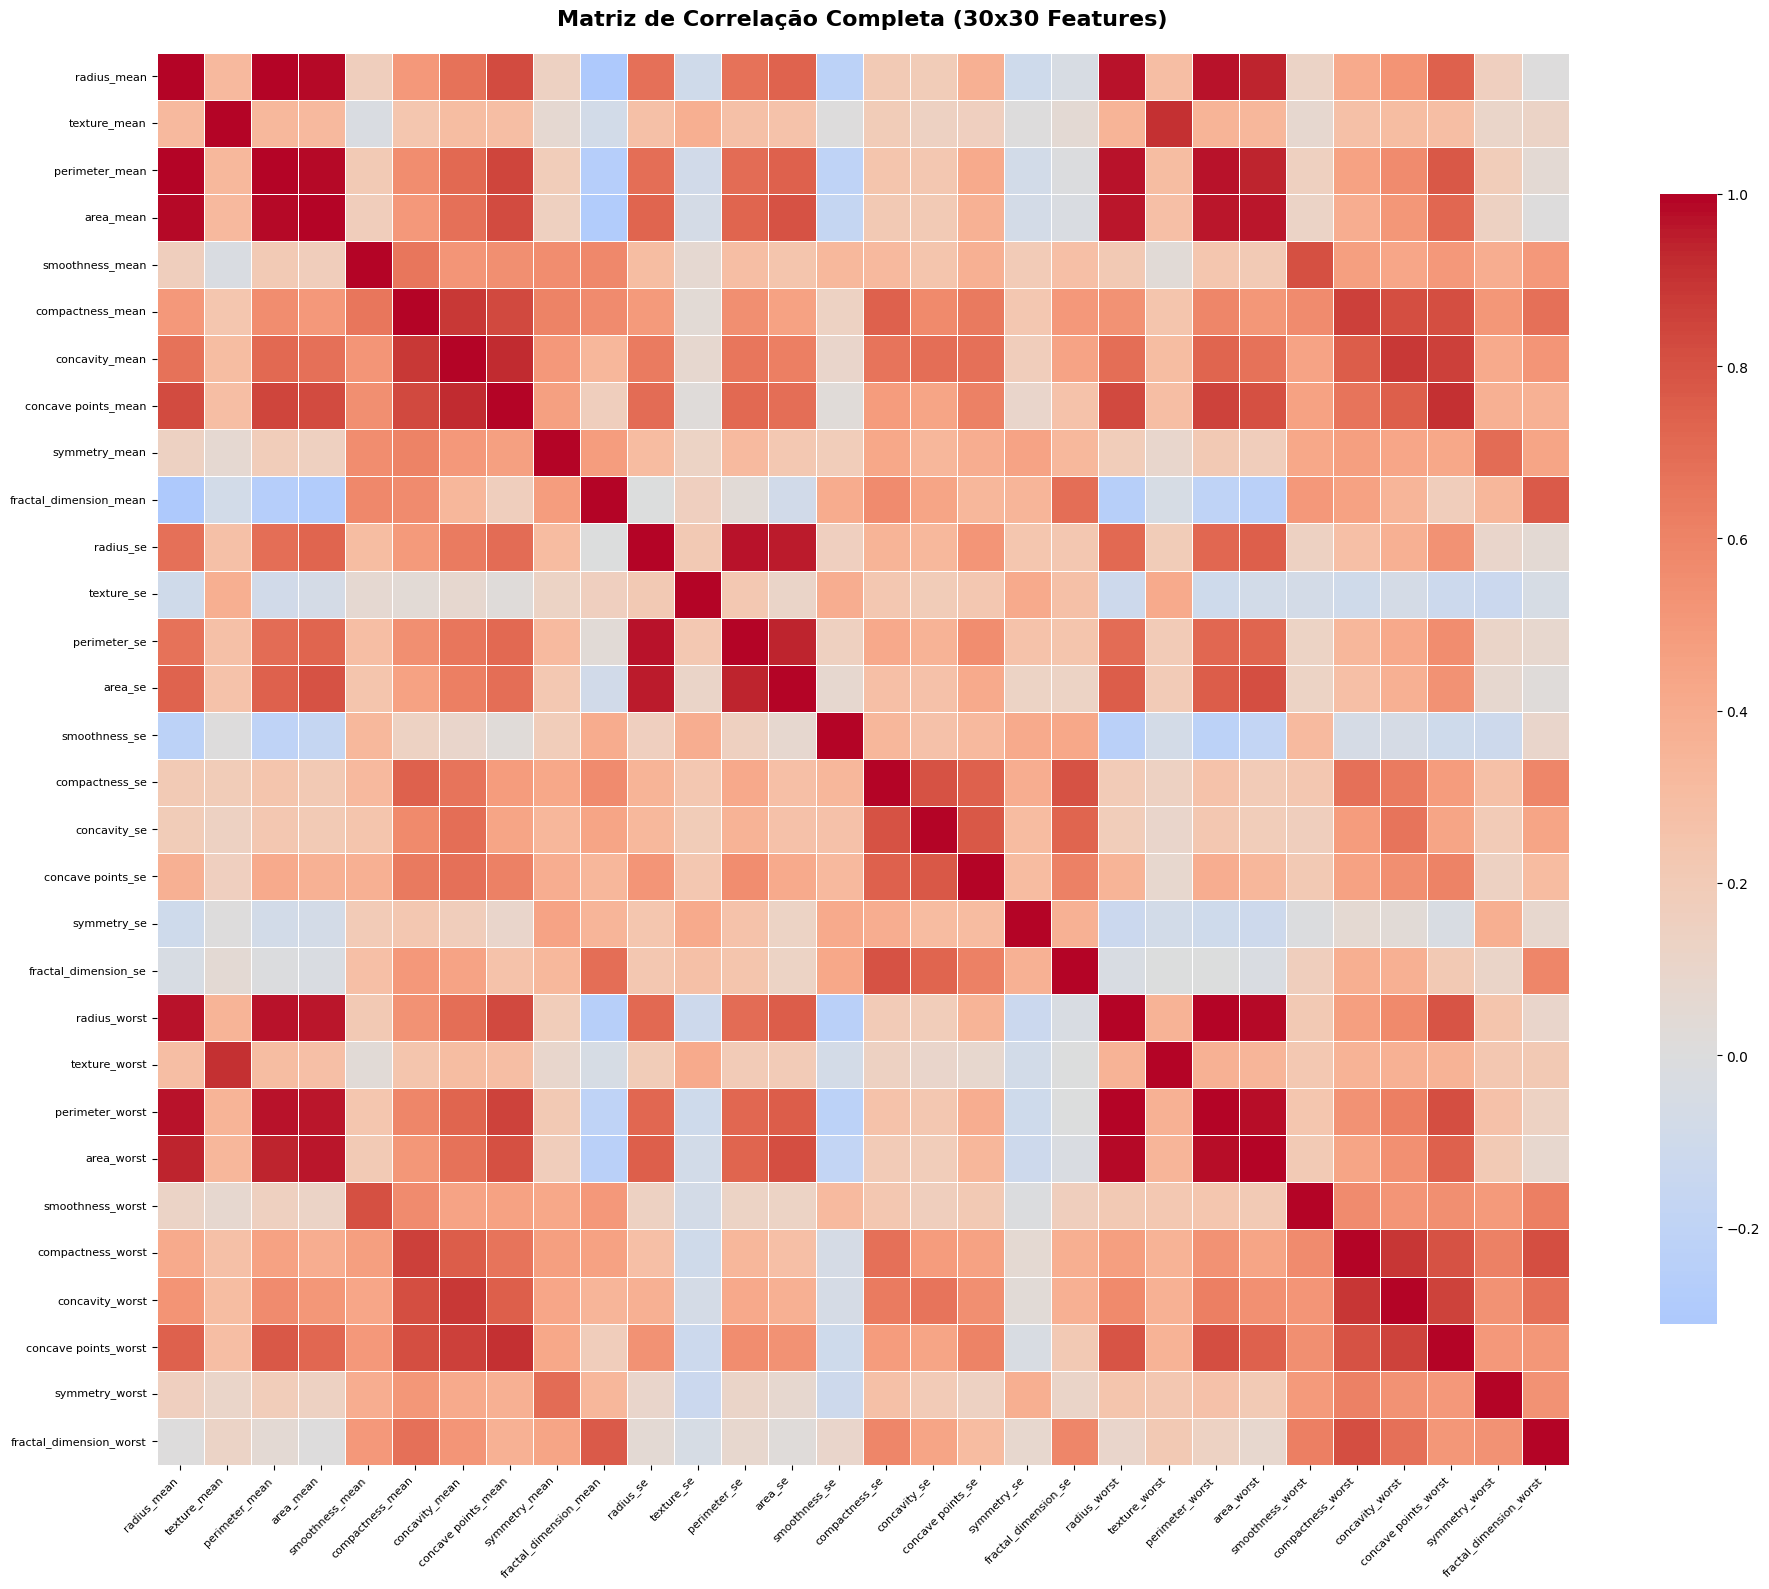

In [58]:
# Heatmap de correlação completa
corr_matrix_all = df_corr[numeric_cols].corr()

# Criar heatmap completo
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix_all, annot=False, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, 
            xticklabels=True, yticklabels=True)
plt.title('Matriz de Correlação Completa (30x30 Features)', fontweight='bold', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


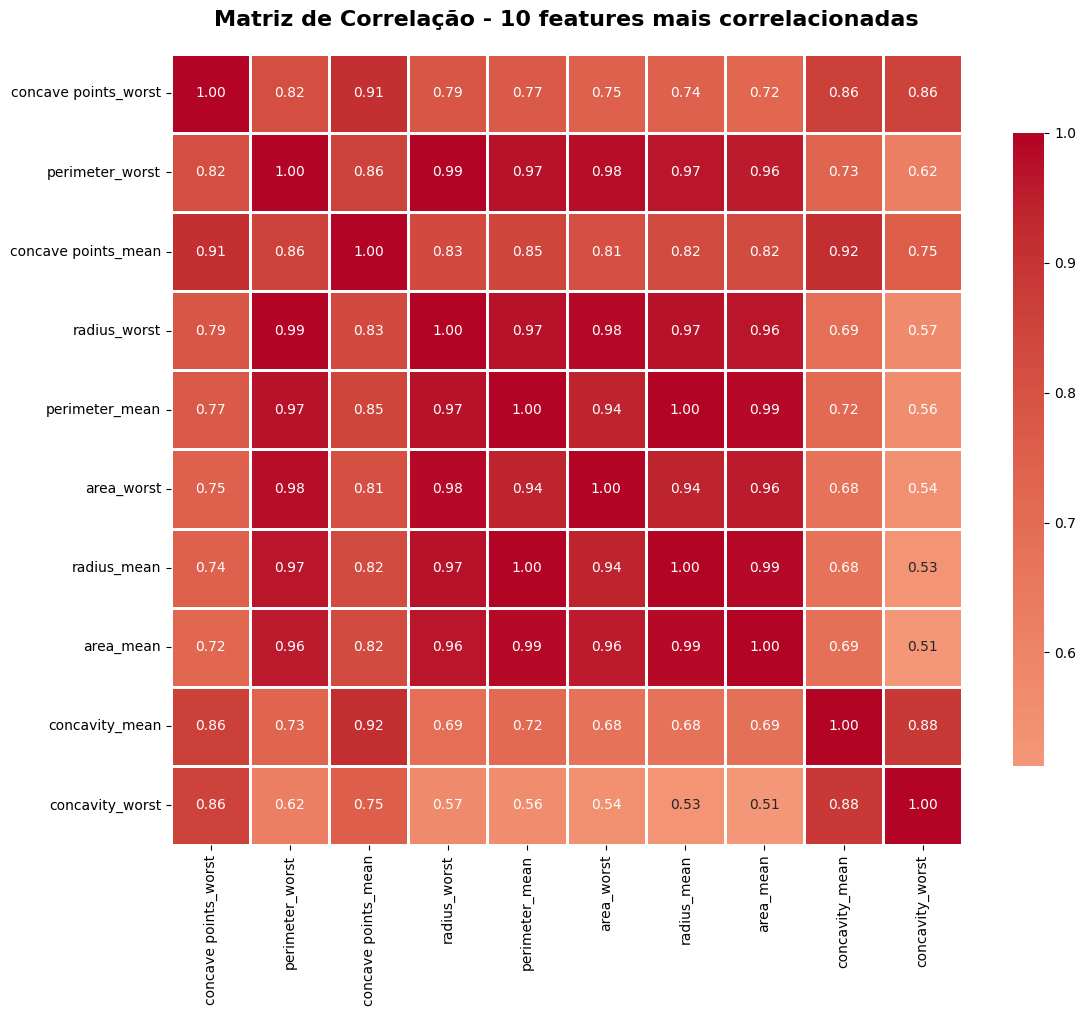

In [59]:
# Seleciona as 10 features mais correlacionadas
top_features = correlation_with_target.head(10).index.tolist()
corr_matrix = df_corr[top_features].corr()

# Criar heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação - 10 features mais correlacionadas', fontweight='bold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


Os gráficos para entender os dados e comparar as features entre as classes Benigno e Maligno.
- Boxplots mostram a distribuição e outliers de cada classe
- Histogramas mostram a forma das distribuições
- Quanto mais separadas as distribuições, melhor a feature para classificação!

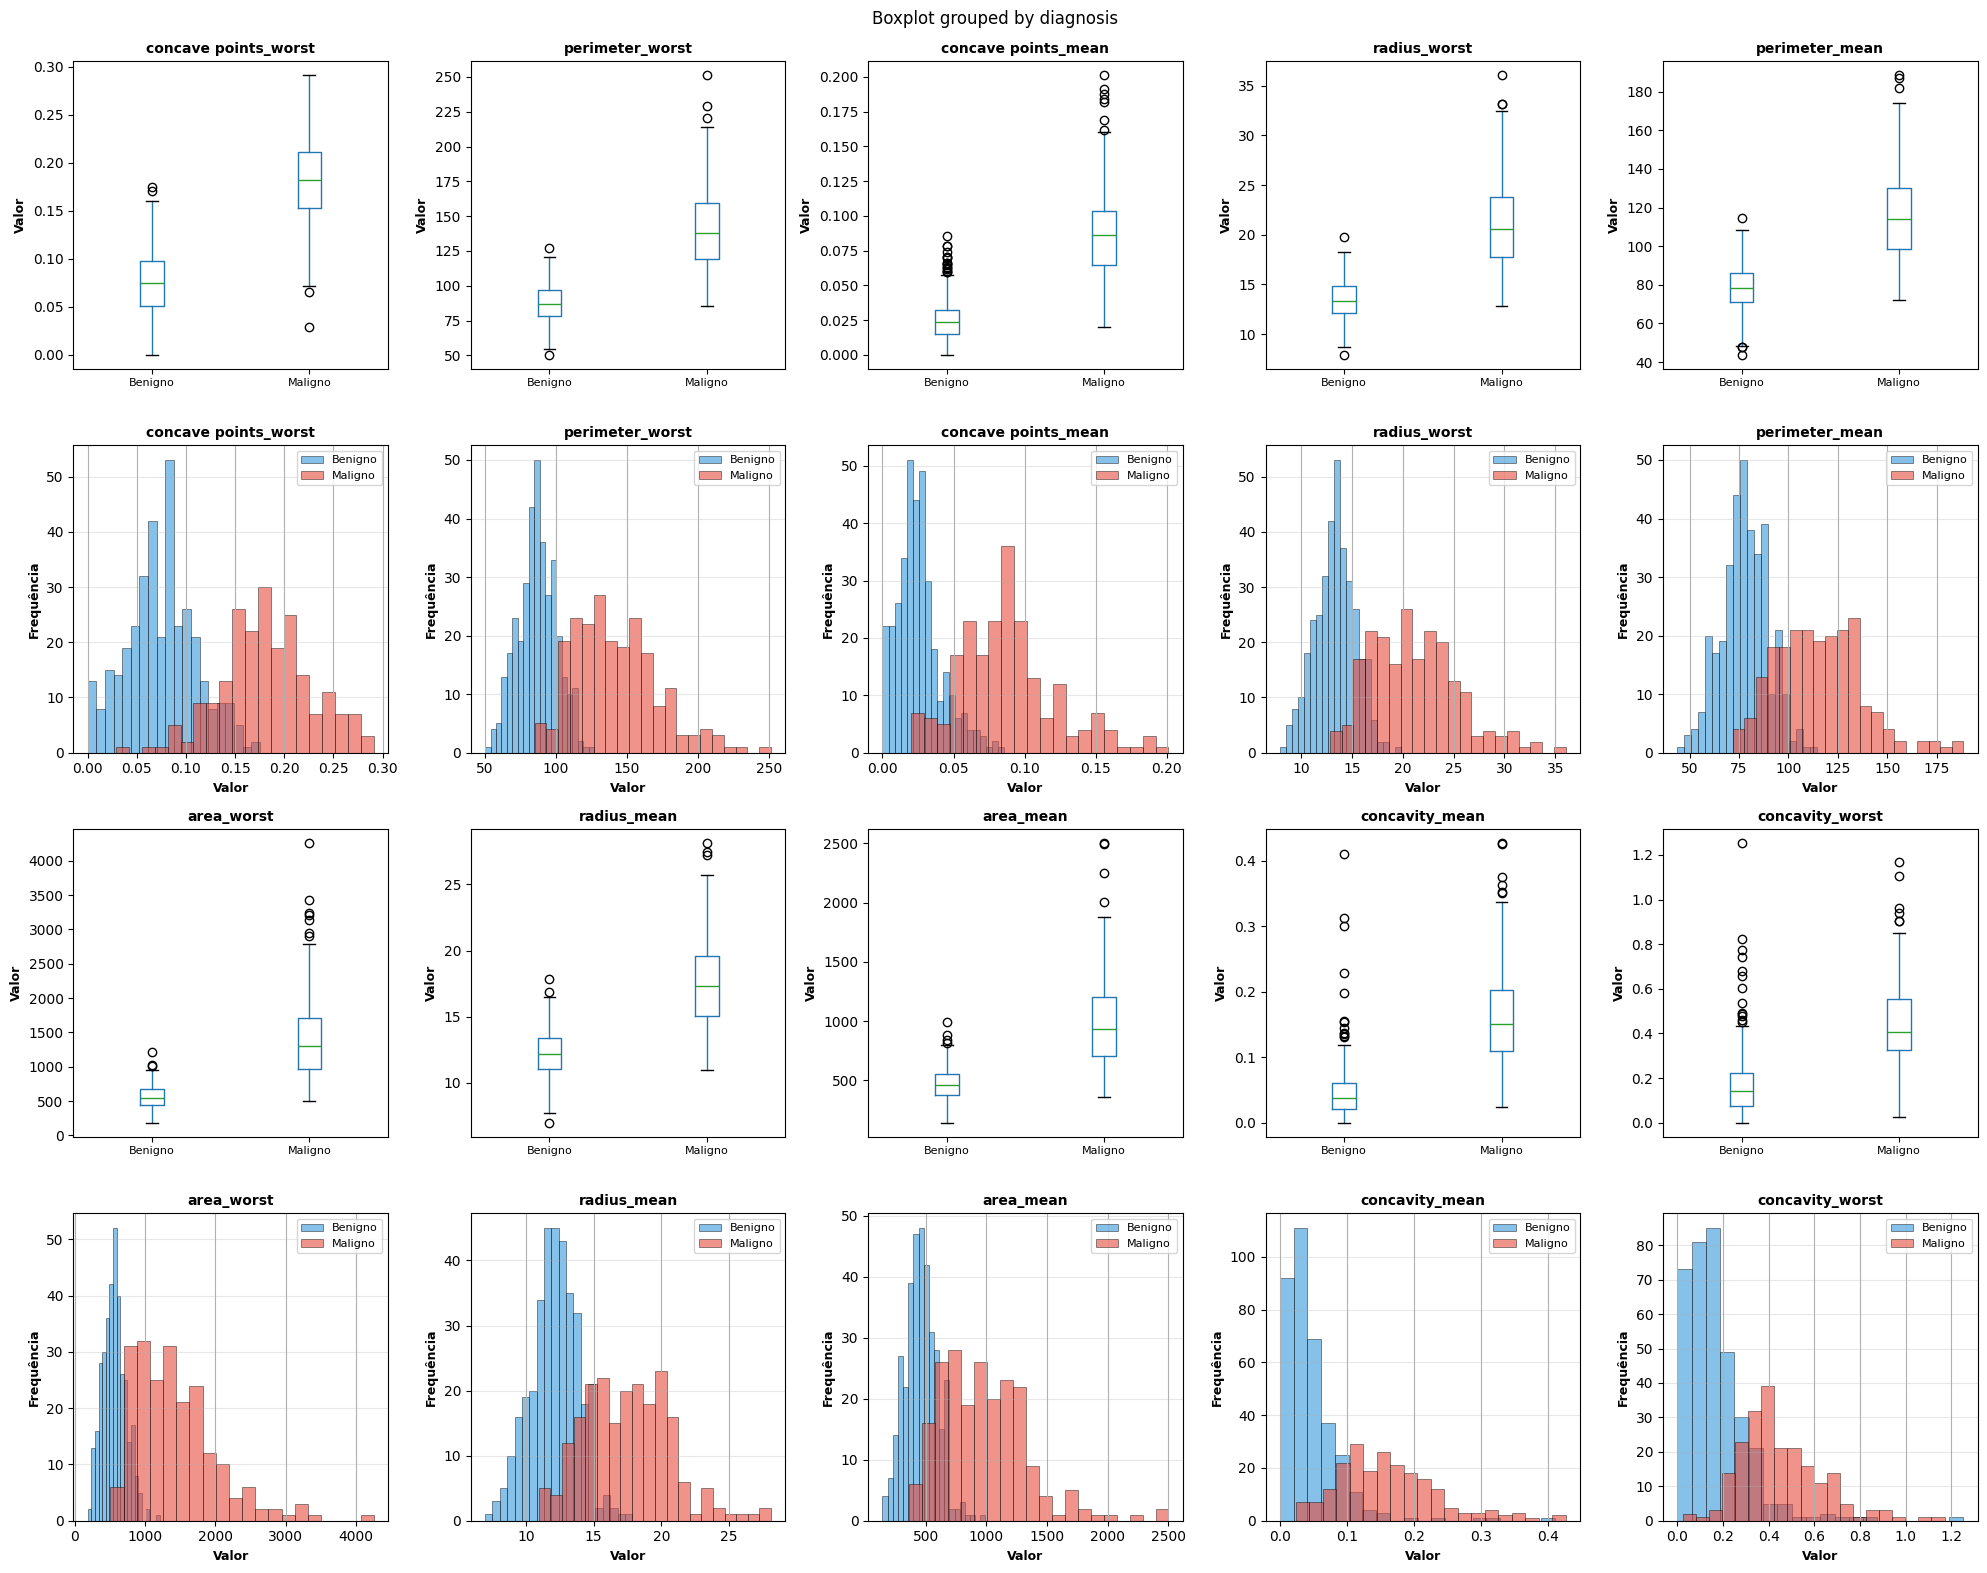

In [60]:
# Seleciona as 10 features para visualização
top_10_features = correlation_with_target.head(10).index.tolist()

# Boxplots e Histogramas
# 4 linhas x 5 colunas = 20 subplots (2 gráficos para cada uma das 10 features)
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle('Distribuições das 10 Features Mais Correlacionadas por Classe', 
              fontweight='bold', fontsize=18, y=0.995)

# Primeiras 5 features (linhas 0 e 1)
for idx, feature in enumerate(top_10_features[:5]):
    # Boxplot (linha 0)
    df.boxplot(column=feature, by='diagnosis', ax=axes[0, idx], grid=False)
    axes[0, idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[0, idx].set_xlabel('')
    axes[0, idx].set_ylabel('Valor', fontweight='bold', fontsize=9)
    axes[0, idx].set_xticklabels(['Benigno', 'Maligno'], fontsize=8)
    
    # Histograma (linha 1)
    df[df['diagnosis'] == 'B'][feature].hist(ax=axes[1, idx], alpha=0.6, label='Benigno', 
                                              color='#3498db', bins=20, edgecolor='black', linewidth=0.5)
    df[df['diagnosis'] == 'M'][feature].hist(ax=axes[1, idx], alpha=0.6, label='Maligno', 
                                              color='#e74c3c', bins=20, edgecolor='black', linewidth=0.5)
    axes[1, idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[1, idx].set_xlabel('Valor', fontweight='bold', fontsize=9)
    axes[1, idx].set_ylabel('Frequência', fontweight='bold', fontsize=9)
    axes[1, idx].legend(fontsize=8, loc='upper right')
    axes[1, idx].grid(alpha=0.3, axis='y')

# Últimas 5 features (linhas 2 e 3)
for idx, feature in enumerate(top_10_features[5:]):
    # Boxplot (linha 2)
    df.boxplot(column=feature, by='diagnosis', ax=axes[2, idx], grid=False)
    axes[2, idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[2, idx].set_xlabel('')
    axes[2, idx].set_ylabel('Valor', fontweight='bold', fontsize=9)
    axes[2, idx].set_xticklabels(['Benigno', 'Maligno'], fontsize=8)
    
    # Histograma (linha 3)
    df[df['diagnosis'] == 'B'][feature].hist(ax=axes[3, idx], alpha=0.6, label='Benigno', 
                                              color='#3498db', bins=20, edgecolor='black', linewidth=0.5)
    df[df['diagnosis'] == 'M'][feature].hist(ax=axes[3, idx], alpha=0.6, label='Maligno', 
                                              color='#e74c3c', bins=20, edgecolor='black', linewidth=0.5)
    axes[3, idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[3, idx].set_xlabel('Valor', fontweight='bold', fontsize=9)
    axes[3, idx].set_ylabel('Frequência', fontweight='bold', fontsize=9)
    axes[3, idx].legend(fontsize=8, loc='upper right')
    axes[3, idx].grid(alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


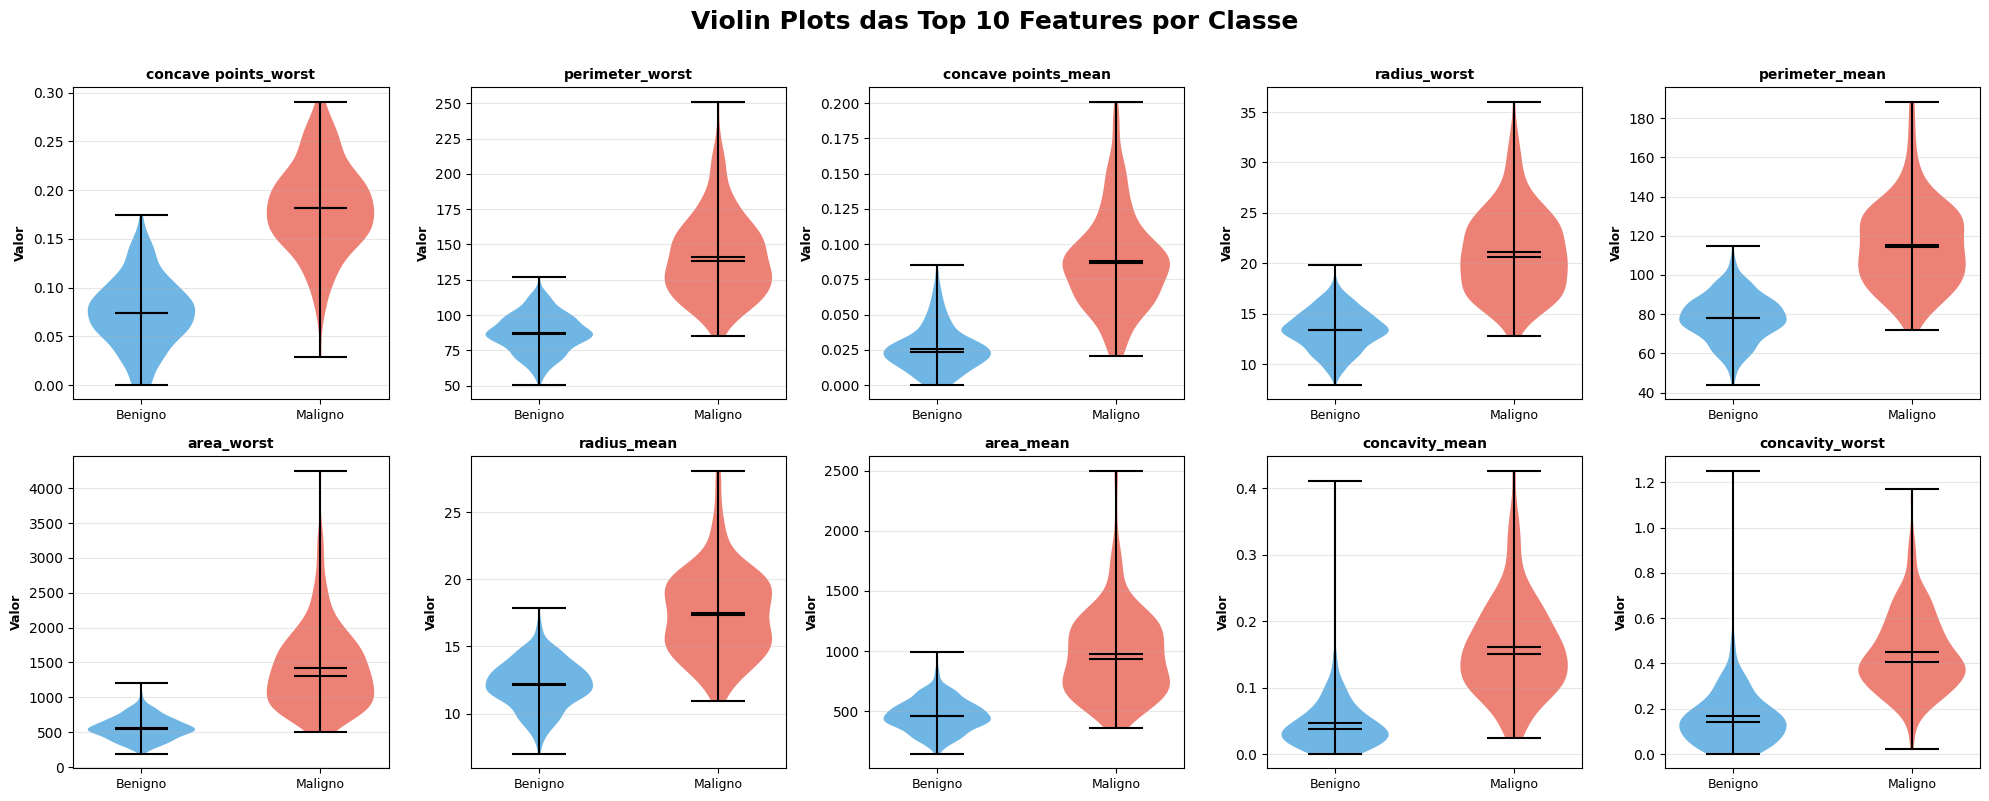

In [61]:
# Violin plots das top 10 features - complementa boxplots
# Mostra a distribuição completa (densidade) além dos quartis
top_10_features = correlation_with_target.head(10).index.tolist()

# Criar violin plots em grid 2x5
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Violin Plots das Top 10 Features por Classe', 
              fontweight='bold', fontsize=18, y=0.995)

axes = axes.flatten()

for idx, feature in enumerate(top_10_features):
    data_benign = df[df['diagnosis'] == 'B'][feature]
    data_malignant = df[df['diagnosis'] == 'M'][feature]
    parts = axes[idx].violinplot([data_benign, data_malignant], positions=[0, 1], 
                                  widths=0.6, showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor('#3498db')
        pc.set_alpha(0.7)
    parts['bodies'][1].set_facecolor('#e74c3c')
    parts['bodies'][1].set_alpha(0.7)
    
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans', 'cmedians'):
        if partname in parts:
            parts[partname].set_color('black')
            parts[partname].set_linewidth(1.5)
    
    axes[idx].set_title(f'{feature}', fontweight='bold', fontsize=10)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Benigno', 'Maligno'], fontsize=9)
    axes[idx].set_ylabel('Valor', fontweight='bold', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


Analisando os gráficos:

1. Boxplots

São gráficos que mostram a distribuição dos dados, exibindo a mediana, quartis e outliers:
- Se as caixas de Benigno e Maligno estão separadas, a feature é útil para classificação
- Se as caixas estão sobrepostas, a feature tem menor poder discriminativo**

2. Histogramas

- Se os histogramas de Benigno e Maligno estão separados, então é uma boa feature para classificação
- Se estão sobrepostos, a feature tende a ser menos discriminativa
- Áreas de sobreposição, é uma região de incerteza onde é difícil distinguir as classes

3. Correlação com o Diagnóstico

A correlação mede a relação linear entre duas variáveis, neste caso, entre uma feature e o diagnóstico.

- Correlação alta (próximo de +1 ou -1) = forte relação linear
- Correlação baixa (próximo de 0) = pouca ou nenhuma relação linear

Portanto:
- Features com alta correlação com o diagnóstico são mais importantes para o modelo
- Essas features ajudam a prever se um tumor é benigno ou maligno
- Correlação positiva: Quando a feature aumenta, maior probabilidade de ser Maligno (M)
- Correlação negativa: Quando a feature aumenta, maior probabilidade de ser Benigno (B)

A separação entre classes indica o quão bem uma feature consegue distinguir entre tumores benignos e malignos.

Características de boa separação:
- Boxplots com caixas separadas (pouca sobreposição)
- Histogramas com picos em posições diferentes
- Área de sobreposição mínima entre as distribuições

Características de má separação:
- Boxplots com muita sobreposição
- Histogramas sobrepostos com picos similares
- Área de sobreposição grande, portanto, difícil distinguir as classes

A variabilidade mede o quanto os valores variam dentro de cada classe.
- Baixa variabilidade = valores consistentes dentro da classe (boxplot com caixa pequena)
- Alta variabilidade = valores muito diferentes (boxplot com caixa grande)
- Baixa variabilidade dentro da classe e com boa separação entre classes = feature ideal

4. Violin Plots

São gráficos que combinam informações de boxplots com a distribuição de densidade dos dados:
- Mostram a distribuição completa (densidade) além dos quartis e mediana
- Complementam os boxplots ao exibir a forma da distribuição de probabilidade
- A largura do violino em cada ponto indica a frequência relativa dos valores nessa região
- Se os violinos de Benigno e Maligno têm formas diferentes e estão separados, a feature é útil para classificação
- Violinos sobrepostos indicam menor poder discriminativo da feature
- Permitem identificar multimodalidade e assimetrias na distribuição dos dados



Conclusão da Análise Exploratória dos Dados

Com base na análise exploratória realizada, podemos tirar as seguintes conclusões sobre o dataset de câncer de mama:

1. Características Gerais do Dataset

O dataset possui 569 amostras e 30 features numéricas que descrevem características das células de tumores de mama. As features representam três tipos de medidas para cada característica: média (mean), erro padrão (se) e pior valor (worst), resultando em 30 características no total.

Não foram encontrados valores ausentes no dataset, o que indica uma base de dados limpa e pronta para análise e modelagem.

2. Distribuição das Classes

O dataset apresenta um desbalanceamento moderado entre as classes:
- 357 casos benignos (62.74%)
- 212 casos malignos (37.26%)
- Razão de balanceamento: 0.59

Embora exista um desbalanceamento, a razão de 0.59 indica que não é crítico, mas deve ser considerado durante a modelagem para evitar viés em favor da classe majoritária (benigna).

3. Qualidade das Features para Classificação

As análises gráficas (boxplots, histogramas e violin plots) revelaram que as 10 features mais correlacionadas apresentam boa separação entre as classes benignas e malignas:
- Features como concave points_worst, perimeter_worst, concave points_mean e radius_worst mostram correlações acima de 0.77 com o diagnóstico
- Os gráficos evidenciam separação clara entre as distribuições das duas classes
- Boxplots com pouca sobreposição indicam features discriminativas
- Histogramas com picos em posições diferentes confirmam a capacidade de distinção entre classes

4. Correlação entre Features

A análise de correlação identificou:
- Features com alta correlação entre si, indicando possível multicolinearidade (como radius, perimeter e area, que são relacionadas geometricamente)
- Features com alta correlação com o target (diagnóstico), essenciais para o modelo preditivo
- O heatmap completo permite identificar grupos de features similares que podem ser redundantes

5. Escalas dos Dados

As features apresentam escalas muito diferentes entre si, o que indica a necessidade de padronização ou normalização antes da aplicação de modelos de Machine Learning sensíveis à escala, como regressão logística, SVM e redes neurais.



In [62]:
# Importar bibliotecas de pré-processamento do scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [63]:
# Separar features 
X = df.drop(columns=['diagnosis'])  # Remove a coluna de diagnóstico
y = df['diagnosis']  # Alvo


print(f"Features (X):")
print(f"Forma: {X.shape}")
print(f"Quantidade de features: {X.shape[1]}")
print(f"Target (y):")
print(f"{y.shape}")
print(f"Valores únicos: {y.unique()}")
print(f"Distribuição:")
print(y.value_counts())


Features (X):
Forma: (569, 30)
Quantidade de features: 30
Target (y):
(569,)
Valores únicos: ['M' 'B']
Distribuição:
diagnosis
B    357
M    212
Name: count, dtype: int64


Convertendo as colunas categóricas em numéricas:


In [64]:
# Converter target para valores numéricos
y = y.map({'B': 0, 'M': 1})
print(f"Valores únicos: {y.unique()}")
print(f"Distribuição:")
print(y.value_counts().sort_index())


Valores únicos: [1 0]
Distribuição:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [65]:
# Obtem os nomes das colunas numéricas
numeric_features = X.columns.tolist()

# Cria o pré-processador usando ColumnTransformer
# Aplicação do StandardScaler em todas as features numéricas (padronização)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)
print(f"Features processadas: {len(numeric_features)}")


Features processadas: 30


In [66]:
# Importar train_test_split
from sklearn.model_selection import train_test_split

# Separar dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,                   
    y,                    
    test_size=0.2,        
    stratify=y,           
    random_state=42       
)

print(f"Dados de treino:")
print(y_train.value_counts().sort_index())

print(f"Conjunto de TESTE:")
print(y_test.value_counts().sort_index())

preprocessor.fit(X_train)
X_train_scaled = preprocessor.transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

Dados de treino:
diagnosis
0    285
1    170
Name: count, dtype: int64
Conjunto de TESTE:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [67]:
# Verificando padronização
import numpy as np

train_means = np.mean(X_train_scaled, axis=0)
print(f"Média das médias: {np.mean(train_means):.6f}")
print(f"Min média: {np.min(train_means):.6f}, Max média: {np.max(train_means):.6f}")

train_stds = np.std(X_train_scaled, axis=0)
print(f"Média dos desvios padrão: {np.mean(train_stds):.6f}")
print(f"Min desvio padrão: {np.min(train_stds):.6f}, Max desvio padrão: {np.max(train_stds):.6f}")

Média das médias: 0.000000
Min média: -0.000000, Max média: 0.000000
Média dos desvios padrão: 1.000000
Min desvio padrão: 1.000000, Max desvio padrão: 1.000000
